## 課題

1.
    教科書p.209以降を読み進め、拡散モデルを用いてMNISTを生成する。ここで、教科書p.236に示されている「エポックごとの生成画像」を作成してもらう。そのために必要なプログラムを、このノートブック上に作成すること。また、学んだことや考察を述べること。

    ただし、アニメーションとして作成してほしいので、[ここを参考に](https://nitic-j-murakami-lab.github.io/PRML-Textbooks/neuralnet/ae.html)すること。


2. 教科書p.237以降を読み進め、学んだことをまとめること。必要であればプログラムを示し、実験を行っても良い。

## 課題１

### 1.ライブラリとデータセットの準備

In [1]:
# packageのimport
import math
from datetime import datetime
from typing import Any, Union, Callable, Type, TypeVar
from tqdm.auto import trange,tqdm
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
plt.style.use("bmh")

# pytorch関連のimport
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms

# animation
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML, display, Markdown

# ハイパーパラメータ
IMG_SIZE = 28
BATCH_SIZE = 128
NUM_TIMESTEPS = 1000  # 拡散過程のステップ数
EPOCHS = 10           # 学習エポック数
LR = 1e-3             # 学習率
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")

# [cite_start](教科書 p.233 [cite: 3265])
preprocess = transforms.Compose([
    transforms.ToTensor(), # PIL画像をTensorに変換し、値を[0, 1]に正規化
])
dataset = torchvision.datasets.MNIST(root='./data', download=True, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

/root/workspace/deffution_model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


### 2.モデル（U-Net）の実装

In [2]:
def pos_encoding(ts, output_dim, device='cpu'):
    # [cite_start](教科書 p.216 [cite: 3239])
    batch_size = len(ts)
    v = torch.zeros(batch_size, output_dim, device=device)
    i = torch.arange(0, output_dim, device=device)
    div_term = 10000 ** (i / output_dim)
    
    for i in range(batch_size):
        t = ts[i]
        v[i, 0::2] = torch.sin(t / div_term[0::2])
        v[i, 1::2] = torch.cos(t / div_term[1::2])
    return v

class ConvBlock(nn.Module):
    # [cite_start](教科書 p.219 [cite: 3243])
    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.mlp = nn.Sequential(
            nn.Linear(time_embed_dim, in_ch),
            nn.ReLU(),
            nn.Linear(in_ch, in_ch)
        )

    def forward(self, x, v):
        N, C, _, _ = x.shape
        v = self.mlp(v)
        v = v.view(N, C, 1, 1)
        y = self.convs(x + v)
        return y

class UNet(nn.Module):
    # [cite_start](教科書 p.220 [cite: 3244])
    def __init__(self, in_ch=1, time_embed_dim=100):
        super().__init__()
        self.time_embed_dim = time_embed_dim
        self.down1 = ConvBlock(in_ch, 64, time_embed_dim)
        self.down2 = ConvBlock(64, 128, time_embed_dim)
        self.bot1 = ConvBlock(128, 256, time_embed_dim)
        self.up2 = ConvBlock(128 + 256, 128, time_embed_dim)
        self.up1 = ConvBlock(128 + 64, 64, time_embed_dim)
        self.out = nn.Conv2d(64, in_ch, 1)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x, timesteps):
        v = pos_encoding(timesteps, self.time_embed_dim, x.device)
        
        x1 = self.down1(x, v)
        p1 = self.maxpool(x1)
        x2 = self.down2(p1, v)
        p2 = self.maxpool(x2)
        
        x = self.bot1(p2, v)
        
        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, v)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, v)
        x = self.out(x)
        return x

### 3.Diffuserクラスの実装

In [3]:
class Diffuser:
    # [cite_start](教科書 p.227-232 [cite: 3258-3263])
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x_0, t):
        t_idx = t - 1
        alpha_bar = self.alpha_bars[t_idx]
        N, C, H, W = x_0.shape
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        
        noise = torch.randn_like(x_0, device=self.device)
        x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise
        return x_t, noise

    def denoise(self, model, x, t):
        t_idx = t - 1
        N, C, H, W = x.shape
        
        alpha = self.alphas[t_idx].view(N, 1, 1, 1)
        alpha_bar = self.alpha_bars[t_idx].view(N, 1, 1, 1)

        # t=1 (t_idx=0) のとき、バッチサイズNに合わせた[1.0, 1.0, ...]というテンソルを生成
        if (t_idx == 0).all():
             alpha_bar_prev = torch.ones_like(alpha_bar, device=self.device)
        else:
            # t > 1 の場合は、t-1のインデックスを使って取得
            alpha_bar_prev = self.alpha_bars[t_idx - 1].view(N, 1, 1, 1)

        model.eval()
        with torch.no_grad():
            eps = model(x, t)
        model.train()

        noise = torch.randn_like(x, device=self.device)
        # tが1の要素だけノイズを0にする（より確実なマスク処理に変更）
        noise_mask = (t != 1).view(N, 1, 1, 1).to(self.device)
        noise = noise * noise_mask

        mu = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps) / torch.sqrt(alpha)
        std = torch.sqrt((1 - alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar))
        
        return mu + std * noise # 標準偏差stdはnoiseに乗算する

    @staticmethod
    def reverse_to_img(x):
        x = x.clamp(0, 1)
        x = (x * 255).to(torch.uint8)
        x = x.cpu()
        to_pil = transforms.ToPILImage()
        return to_pil(x)

    def sample(self, model, x_shape=(10, 1, 28, 28)):
        batch_size = x_shape[0]
        x = torch.randn(x_shape, device=self.device)

        for i in tqdm(range(self.num_timesteps, 0, -1), desc="Sampling"):
            t = torch.tensor([i] * batch_size, device=self.device, dtype=torch.long)
            x = self.denoise(model, x, t)
            
        images = [self.reverse_to_img(x[i]) for i in range(batch_size)]
        return images

### 4.学習ループと可視化

Epoch 1/10: 100%|██████████| 469/469 [00:39<00:00, 12.01it/s]


Epoch 1/10 | Loss: 0.0452


Epoch 2/10: 100%|██████████| 469/469 [00:38<00:00, 12.23it/s]


Epoch 2/10 | Loss: 0.0259


Epoch 3/10: 100%|██████████| 469/469 [00:38<00:00, 12.15it/s]


...

Epoch 8/10 | Loss: 0.0187


Epoch 9/10: 100%|██████████| 469/469 [00:39<00:00, 11.98it/s]


Epoch 9/10 | Loss: 0.0181


Epoch 10/10: 100%|██████████| 469/469 [00:39<00:00, 11.79it/s]

Epoch 10/10 | Loss: 0.0180


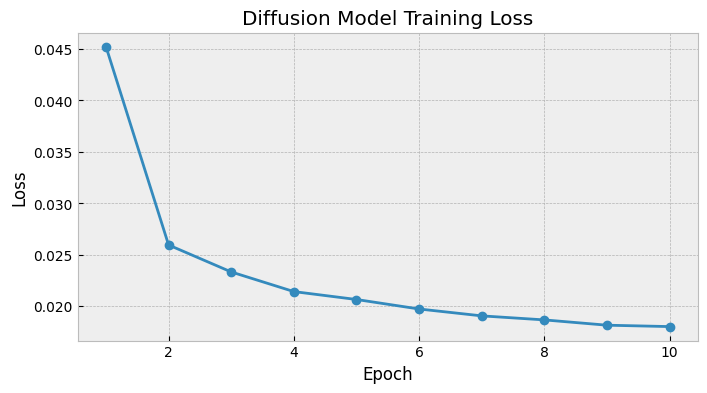

### エポックごとの生成画像

In [4]:
model = UNet().to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR)
diffuser = Diffuser(NUM_TIMESTEPS, device=DEVICE)

losses = []
generated_images_per_epoch = []

for epoch in range(EPOCHS):
    loss_sum = 0.0
    
    # エポック開始時に画像を生成して保存
    model.eval()
    generated_images = diffuser.sample(model)
    generated_images_per_epoch.append(generated_images)
    model.train()

    for images, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        optimizer.zero_grad()
        x = images.to(DEVICE)
        
        t = torch.randint(1, NUM_TIMESTEPS + 1, (len(x),), device=DEVICE)
        x_noisy, noise = diffuser.add_noise(x, t)
        noise_pred = model(x_noisy, t)
        
        loss = F.mse_loss(noise, noise_pred)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
    
    loss_avg = loss_sum / len(dataloader)
    losses.append(loss_avg)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {loss_avg:.4f}')

# --- 損失関数のグラフ化 ---
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion Model Training Loss')
plt.grid(True)
plt.show()

# --- アニメーションの作成と表示 ---
fig = plt.figure(figsize=(10, 2))
plt.axis('off')
ims = []

for i, images in enumerate(generated_images_per_epoch):
    grid_img = torchvision.utils.make_grid(
        [transforms.ToTensor()(img) for img in images], nrow=10
    ).permute(1, 2, 0)
    
    im = plt.imshow(grid_img, animated=True)
    ttl = plt.text(0.5, 1.01, f'Epoch {i}', horizontalalignment='center', verticalalignment='bottom', transform=plt.gca().transAxes, fontsize=12)
    ims.append([im, ttl])

anim = ArtistAnimation(fig, ims, interval=500, repeat_delay=1000)
plt.close()

display(Markdown("### エポックごとの生成画像"))
display(HTML(anim.to_jshtml()))

### 学んだ事
- 拡散モデルの基本
    - 拡散モデルは、元の画像に少しずつノイズを加えていき、最終的に完全なノイズ画像にする。そこから元の画像を復元する。
    - 元の画像を復元する際は、U-Netアーキテクチャで学習したモデルを用いてノイズを取り除いていく事で、新しい画像を生成する。
- U-Netアーキテクチャ
    - 画像の全体的な構造をとらえるエンコーダ部分と、詳細を復元するデコーダ部分から成り、その間の「スキップ接続」によって高精細な画像生成を可能にしている。
    - 拡散モデルでは、どのノイズレベルに対応する処理なのかをモデルに伝える必要がある。
    - 今回はpos_encoding（Sinusoidal Positional Encoding）を用いてタイムステップをベクトルに変換し、U-Netの各層に入力することで、モデルが時間に応じたノイズ除去を学習できるようになっている。
- `ArtistAnimation`を用いると、生成過程をアニメーションにする事が出来る。

### 考察
- 損失の変化について
    - 損失は学習初期に大幅に減少し、その後は緩やかに減少を続けている。
    - Epoch10でもまだ損失が下がり続けているため、学習回数を増やせばまだ性能が向上すると考えられる。
- 生成された画像の品質
    - Epoch1,2では数字に見える物が殆ど存在しない。
    - Epoch3で初めて5,6,7,8,9のような形の物が生成された。
    - Epoch6では2,3,4のような物が高精度で生成されたが、それ以外の文字は精度が下がっているように感じる。
    - Epoch9では、全ての画像が何の文字を表しているかギリギリ分かる程度まで学習が進んだ。これは、適切に学習を行えたのだと考えられる。
    - VAEでは画像がかなりぼやけていたが、拡散モデルで生成された画像はかなりくっきりしている。
- 生成画像の品質を向上させるには
    - Epoch10でも損失が低下していたため、学習回数を増やせば品質が向上すると考えられる。
    - U-Netの各層のチャンネル数を増やす（例: 64→128）。または層を深くする事で、モデルの表現力を高める。
    - U-Netに「Self-Attention」ブロックを組み込むことで、画像内の大域的な関係性を捉える能力が向上し、より構造的に整った画像の生成が期待できる。

## 課題２：拡散モデルの応用

## 1. 条件付き拡散モデル (Conditional Diffusion Models)
### 目的
y（例：数字のラベル「5」や、「馬に乗る宇宙飛行士」というテキスト）を与えて、その条件に合った画像xを生成する。  
これは確率分布p(x|y)をモデル化することに相当。

### 仕組み
U-Netモデルに、ノイズ画像x_tと時刻tだけでなく、条件yも入力する。

実装例（ラベル条件）:
MNISTのようなクラスラベルの場合、nn.Embedding層を使ってラベル（例：整数5）をベクトルに変換する。  
そして、そのベクトルを時刻tから作られたベクトルに足し合わせることで、条件情報をモデルに組み込む。

## 2. ガイダンス (Guidance)
ガイダンスは、モデルが生成する画像が与えられた条件により強く従うように誘導するための技術。スコア関数の概念が重要。

### スコア関数
データの対数確率密度の、データ自身に関する勾配$(∇_{x_t}logP(x_t))$の事。これは、画像x_tを少し変化させたときに、その画像の存在確率が最も高まる方向を示す。  
拡散モデルが予測するノイズ$\epsilon$とスコア関数は、ほぼ同じ情報を持っていることが数学的に示されている。

### 分類器ガイダンス (Classifier Guidance)
- 仕組み：別途学習させた分類器（画像がどのクラスに属するかを判定するモデル）を利用。
- 生成途中のノイズ画像x_tを分類器に入力し「どうすればもっとクラスyらしくなるか」という勾配情報を得て、その方向に画像を少しだけ修正する事で、生成結果がより条件に沿ったものになる。

### 分類器なしガイダンス (Classifier-Free Guidance)
- 目的：分類器を別途用意する手間を省き、拡散モデル単体でガイダンスを実現する、より実用的な手法。
- 仕組み：
    - 1.学習時: モデルを学習させる際、一定の確率で条件yを与えずに（条件なしで）学習させる。これにより、1つのモデルが条件付き生成と条件なし生成の両方をできるようになる。
    - 2.生成時：
        - 条件付きでノイズを予測$ϵ_θ(x_t,y)$
        - 条件なしでノイズを予測$ϵ_θ(x_t,0)$
この2つの予測の差分を利用して、条件の方向性を強調した最終的なノイズを計算する。  
`予測ノイズ = (条件なし予測) + γ * ((条件付き予測) - (条件なし予測))`

## 3.Stable Diffusionの仕組み
Stable Diffusionは、ここまでの技術を組み合わせた、非常に高性能なテキストto画像生成モデルである 。
### 主な特徴
#### 潜在空間での拡散 (Latent Diffusion)
高解像度のピクセル画像を直接扱うのではなく、VAEのようなオートエンコーダで一度低次元の潜在空間に圧縮する。  
それから、計算コストが非常に低いこの潜在空間上で拡散・逆拡散プロセスを実行し、最後にデコーダで高解像度画像に戻す。

#### CLIP テキストエンコーダ
入力されたテキスト（プロンプト）を意味のあるベクトルに変換するため、画像とテキストの関係性を学習したCLIPという強力なモデルを使用。

#### Cross-Attentionによる条件付け
CLIPによって得られたテキストのベクトルを、U-Netの中間層にCross-Attentionという仕組みで組み込む。これにより、テキストのどの部分が画像のどの部分に対応するのかをモデルが「注意」しながら画像を生成できる。

## 実験：条件付き拡散モデルの実装

/root/workspace/deffution_model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Epoch 1/15: 100%|██████████| 469/469 [00:39<00:00, 11.97it/s]


Epoch 1/15 | Loss: 0.0497


Epoch 2/15: 100%|██████████| 469/469 [00:38<00:00, 12.08it/s]


...

Epoch 13/15 | Loss: 0.0169


Epoch 14/15: 100%|██████████| 469/469 [00:39<00:00, 11.90it/s]


Epoch 14/15 | Loss: 0.0163


Epoch 15/15: 100%|██████████| 469/469 [00:38<00:00, 12.13it/s]

Epoch 15/15 | Loss: 0.0164


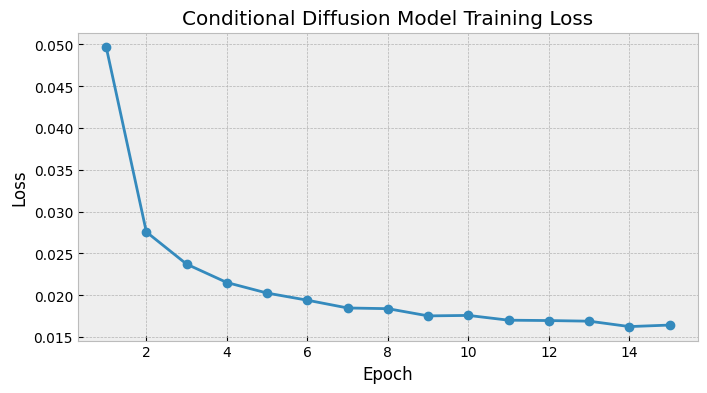

Sampling: 100%|██████████| 1000/1000 [00:04<00:00, 225.86it/s]


### 生成された画像

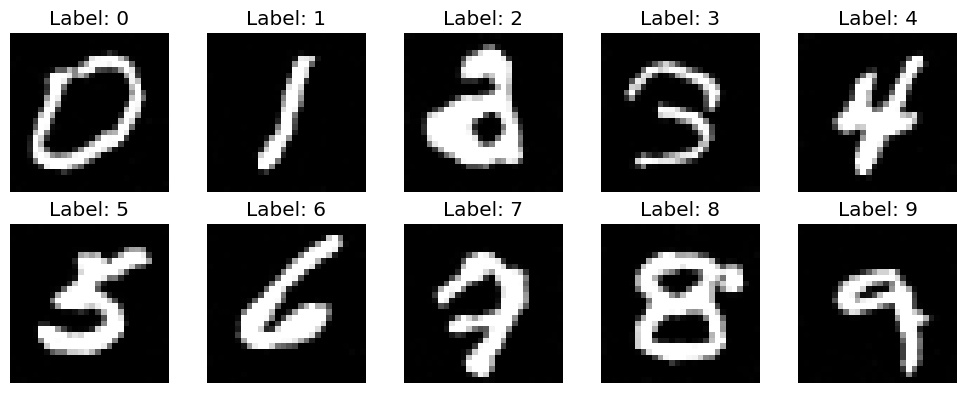

In [2]:
# --- 1.パッケージのインポートとハイパーパラメータ設定 ---
# packageのimport
import math
from datetime import datetime
from typing import Any, Union, Callable, Type, TypeVar
from tqdm.auto import trange,tqdm
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
plt.style.use("bmh")

# pytorch関連のimport
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# animation
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML, display, Markdown

# ハイパーパラメータ
IMG_SIZE = 28
BATCH_SIZE = 128
NUM_TIMESTEPS = 1000
EPOCHS = 15  # 条件を学習するため、少しエポック数を増やします
LR = 1e-3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_LABELS = 10 # MNISTのクラス数 (0~9)

print(f"Using device: {DEVICE}")

# --- 2.データセットの準備 (変更なし) ---
preprocess = transforms.ToTensor()
dataset = torchvision.datasets.MNIST(root='./data', download=True, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- 3.モデル（条件付きU-Net）の実装 ---

def pos_encoding(ts, output_dim, device='cpu'):
    # (教科書 p.216)
    batch_size = len(ts)
    v = torch.zeros(batch_size, output_dim, device=device)
    i = torch.arange(0, output_dim, device=device)
    div_term = 10000 ** (i / output_dim)
    
    for i in range(batch_size):
        t = ts[i]
        v[i, 0::2] = torch.sin(t / div_term[0::2])
        v[i, 1::2] = torch.cos(t / div_term[1::2])
    return v

class ConvBlock(nn.Module):
    # (教科書 p.219)
    def __init__(self, in_ch, out_ch, time_embed_dim):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        self.mlp = nn.Sequential(
            nn.Linear(time_embed_dim, in_ch),
            nn.ReLU(),
            nn.Linear(in_ch, in_ch)
        )

    def forward(self, x, v):
        N, C, _, _ = x.shape
        v = self.mlp(v)
        v = v.view(N, C, 1, 1)
        y = self.convs(x + v)
        return y

class UNetCond(nn.Module): # UNetCond に変更
    # [cite_start](教科書 p.240-241 [cite: 4270-4273])
    def __init__(self, in_ch=1, time_embed_dim=100, num_labels=None): # num_labels を追加
        super().__init__()
        self.time_embed_dim = time_embed_dim
        self.down1 = ConvBlock(in_ch, 64, time_embed_dim)
        self.down2 = ConvBlock(64, 128, time_embed_dim)
        self.bot1 = ConvBlock(128, 256, time_embed_dim)
        self.up2 = ConvBlock(128 + 256, 128, time_embed_dim)
        self.up1 = ConvBlock(128 + 64, 64, time_embed_dim)
        self.out = nn.Conv2d(64, in_ch, 1)
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')
        
        # ラベル情報をベクトルに変換するためのEmbedding層を追加
        if num_labels is not None:
            self.label_emb = nn.Embedding(num_labels, time_embed_dim)

    def forward(self, x, timesteps, labels=None): # labels を引数に追加
        # 正弦波位置エンコーディングで時刻をベクトル化
        v = pos_encoding(timesteps, self.time_embed_dim, x.device)
        
        # ラベルが与えられた場合、ラベルの埋め込みを時刻ベクトルに加算
        if labels is not None:
            v += self.label_emb(labels)
        
        x1 = self.down1(x, v)
        p1 = self.maxpool(x1)
        x2 = self.down2(p1, v)
        p2 = self.maxpool(x2)
        x = self.bot1(p2, v)
        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, v)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, v)
        x = self.out(x)
        return x

# --- 4.Diffuserクラスの実装 (変更あり) ---

class Diffuser:
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x_0, t):
        t_idx = t - 1
        alpha_bar = self.alpha_bars[t_idx]
        N, C, H, W = x_0.shape
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        noise = torch.randn_like(x_0, device=self.device)
        x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise
        return x_t, noise

    def denoise(self, model, x, t, labels): # labels を引数に追加
        t_idx = t - 1
        N, C, H, W = x.shape
        alpha = self.alphas[t_idx].view(N, 1, 1, 1)
        alpha_bar = self.alpha_bars[t_idx].view(N, 1, 1, 1)

        if (t_idx == 0).all():
             alpha_bar_prev = torch.ones_like(alpha_bar, device=self.device)
        else:
            alpha_bar_prev = self.alpha_bars[t_idx - 1].view(N, 1, 1, 1)

        model.eval()
        with torch.no_grad():
            eps = model(x, t, labels) # labels をモデルに渡す
        model.train()

        noise = torch.randn_like(x, device=self.device)
        noise_mask = (t != 1).view(N, 1, 1, 1).to(self.device)
        noise = noise * noise_mask

        mu = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * eps) / torch.sqrt(alpha)
        std = torch.sqrt((1 - alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar))
        
        return mu + std * noise

    @staticmethod
    def reverse_to_img(x):
        x = x.clamp(0, 1)
        x = (x * 255).to(torch.uint8)
        x = x.cpu()
        to_pil = transforms.ToPILImage()
        return to_pil(x)

    def sample(self, model, x_shape=(10, 1, 28, 28), labels=None): # labels を引数に追加
        batch_size = x_shape[0]
        x = torch.randn(x_shape, device=self.device)

        if labels is None:
            # ラベルが指定されなかった場合、0~9のラベルを自動で作成
            labels = torch.arange(batch_size, device=self.device) % NUM_LABELS
        
        for i in tqdm(range(self.num_timesteps, 0, -1), desc="Sampling"):
            t = torch.tensor([i] * batch_size, device=self.device, dtype=torch.long)
            x = self.denoise(model, x, t, labels) # labels を渡す
            
        images = [self.reverse_to_img(x[i]) for i in range(batch_size)]
        return images, labels

# --- 5.学習ループと可視化 ---

model = UNetCond(num_labels=NUM_LABELS).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR)
diffuser = Diffuser(NUM_TIMESTEPS, device=DEVICE)

losses = []

for epoch in range(EPOCHS):
    loss_sum = 0.0
    
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        optimizer.zero_grad()
        x = images.to(DEVICE)
        labels = labels.to(DEVICE) # ラベルもGPUに送る
        
        t = torch.randint(1, NUM_TIMESTEPS + 1, (len(x),), device=DEVICE)
        x_noisy, noise = diffuser.add_noise(x, t)
        
        noise_pred = model(x_noisy, t, labels) # モデルにラベルを渡す
        
        loss = F.mse_loss(noise, noise_pred)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item()
    
    loss_avg = loss_sum / len(dataloader)
    losses.append(loss_avg)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {loss_avg:.4f}')

# --- 損失関数のグラフ化 ---
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Conditional Diffusion Model Training Loss')
plt.grid(True)
plt.show()


# --- 6.条件付き画像の生成と表示 ---

def show_images(images, labels, rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    for i, (image, label) in enumerate(zip(images, labels)):
        ax = axes.flatten()[i]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"Label: {label.item()}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

model.eval()
# 0から9までの画像を1枚ずつ生成
target_labels = torch.arange(10, device=DEVICE)
generated_images, generated_labels = diffuser.sample(model, x_shape=(10, 1, 28, 28), labels=target_labels)

display(Markdown("### 生成された画像"))
show_images(generated_images, generated_labels)

## 結果から
結果を見ると、とても高精度で条件通りの文字が生成されている。2と7と6は形が崩れているが、その他はどの数字かはっきり判別できる程に正確である。  
条件付き拡散モデルは、大まかに言うと、データローダーから画像とラベルを一緒に取り出して学習させ、生成時にラベルを指定するという処理を追加する事で実装できた。